##Iris Flower Classification

In [16]:
%pip install ucimlrepo

In [17]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

iris=fetch_ucirepo(id=53)

In [18]:
X = iris.data.features
y = iris.data.targets

df_combined = X.copy()
df_combined['class'] = y['class']

display(df_combined.head())

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [19]:
df_combined.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [20]:
df_combined.shape

(150, 5)

In [21]:
df_combined.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [22]:
df_combined.duplicated().sum()

np.int64(3)

In [23]:
df_combined.drop_duplicates(inplace=True)

In [24]:
# df_combined.duplicated().sum()

In [25]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  147 non-null    float64
 1   sepal width   147 non-null    float64
 2   petal length  147 non-null    float64
 3   petal width   147 non-null    float64
 4   class         147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.9+ KB


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df_combined['class'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

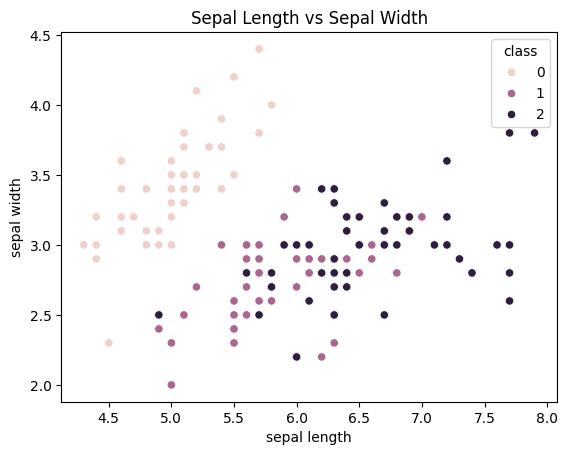

In [55]:
sns.scatterplot(
    data=df_combined,
    x='sepal length',
    y='sepal width',
    hue='class'
)

plt.title('Sepal Length vs Sepal Width')
plt.savefig('/content/scatter_sepal_length_vs_sepal_width.png', dpi=300, bbox_inches='tight')
plt.show()

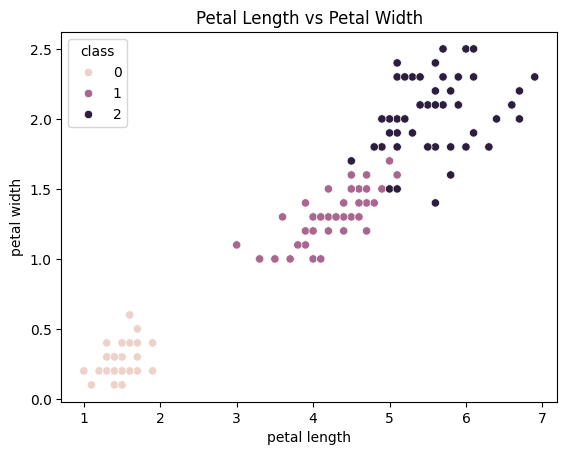

In [54]:
sns.scatterplot(
    data=df_combined,
    x='petal length',
    y='petal width',
    hue='class'
)

plt.title('Petal Length vs Petal Width')
plt.savefig('/content/scatter_petal_length_vs_petal_width.png', dpi=300, bbox_inches='tight')
plt.show()

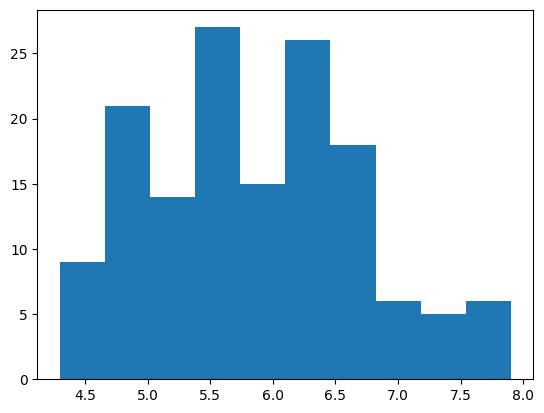

In [53]:
plt.hist(x=df_combined['sepal length'])
plt.savefig('/content/hist_sepal_length.png', dpi=300, bbox_inches='tight')
plt.show()

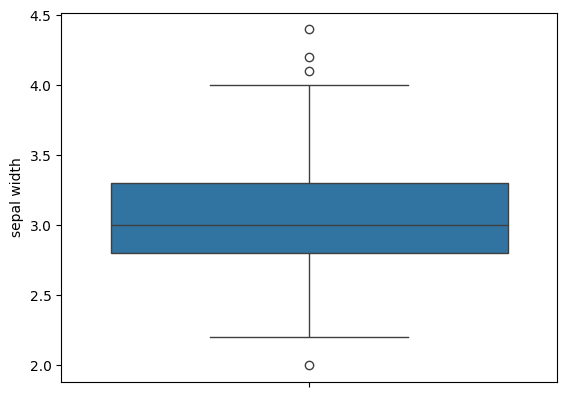

In [52]:
sns.boxplot(df_combined['sepal width'])
plt.savefig('/content/boxplot_sepal_width.png', dpi=300, bbox_inches='tight')
plt.show()

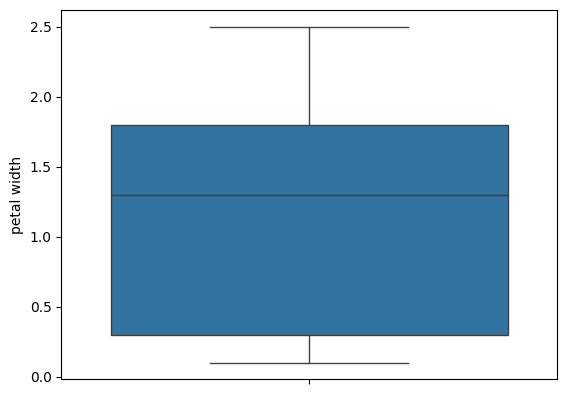

In [51]:
sns.boxplot(df_combined['petal width'])
plt.savefig('/content/boxplot_petal_width.png', dpi=300, bbox_inches='tight')
plt.show()

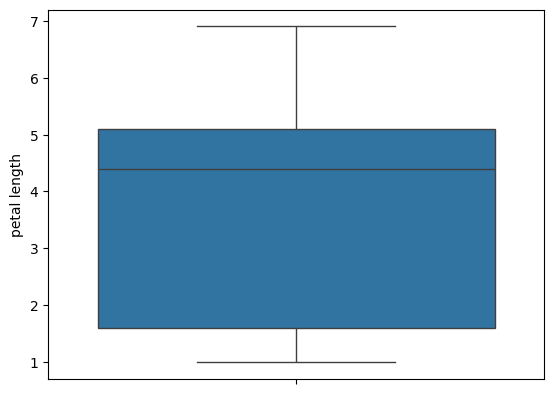

In [50]:
sns.boxplot(df_combined['petal length'])
plt.savefig('/content/boxplot_petal_length.png', dpi=300, bbox_inches='tight')
plt.show()

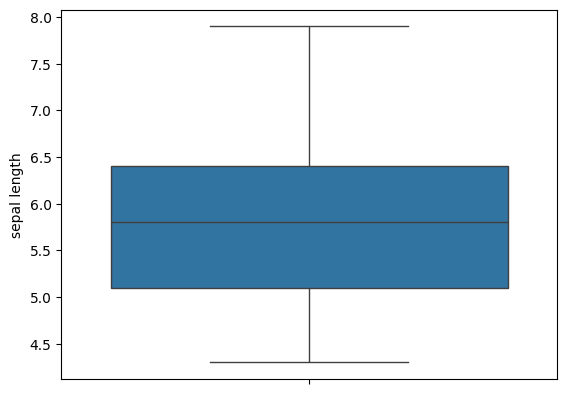

In [34]:
sns.boxplot(df_combined['sepal length'])
plt.savefig('/content/sepal_length_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

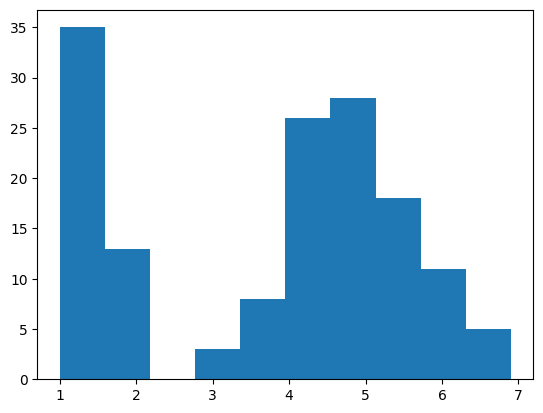

In [49]:
plt.hist(df_combined['petal length'],bins=10)
plt.savefig('/content/hist_petal_length.png', dpi=300, bbox_inches='tight')

In [36]:
corr=df_combined.corr(numeric_only=True)
corr.sort_values('petal length',ascending=False)

,sepal length,sepal width,petal length,petal width
petal length,0.871305,-0.421057,1.000000,0.961883
petal width,0.817058,-0.356376,0.961883,1.000000
sepal length,1.000000,-0.109321,0.871305,0.817058
sepal width,-0.109321,1.000000,-0.421057,-0.356376


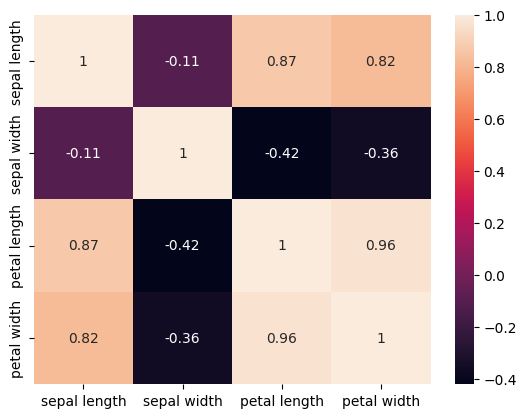

In [37]:
sns.heatmap(corr,annot=True)
plt.savefig('/content/heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_combined['class'] = le.fit_transform(df_combined['class'])

In [39]:
df_combined.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [40]:
df_combined.isnull().sum()

,0
sepal length,0
sepal width,0
petal length,0
petal width,0
class,0


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score
from sklearn.preprocessing import StandardScaler

In [42]:
X = df_combined.drop('class',axis=1)
y=df_combined['class']

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [45]:
m1=LogisticRegression()
m1.fit(X_train_scaled,y_train)
y_pred1=m1.predict(X_test_scaled)
m2=DecisionTreeClassifier()
m2.fit(X_train,y_train)
y_pred2=m2.predict(X_test)
m3=KNeighborsClassifier()
m3.fit(X_train_scaled,y_train)
y_pred3=m3.predict(X_test_scaled)


In [46]:
results=[]
model={
    'LogisticRegression':m1,
    'DecisionTreeClassifier':m2,
    'KNeighboursClassifier':m3
}
predictions={
    'LogisticRegression':y_pred1,
    'DecisionTreeClassifier':y_pred2,
    'KNeighboursClassifier':y_pred3
}
for name in model:
  results.append([
      name,
      accuracy_score(y_test,predictions[name]),
      precision_score(y_test,predictions[name],average='weighted'),
      confusion_matrix(y_test,predictions[name])
  ])

In [47]:
combined_df=pd.DataFrame(results,columns=['Model','Accuracy_Score','Precision_Score','Confusion_matrix'])

In [48]:
combined_df

,Model,Accuracy_Score,Precision_Score,Confusion_matrix
0,LogisticRegression,0.933333,0.933333,"[[11, 0, 0], [0, 9, 1], [0, 1, 8]]"
1,DecisionTreeClassifier,0.966667,0.970000,"[[11, 0, 0], [0, 9, 1], [0, 0, 9]]"
2,KNeighboursClassifier,0.933333,0.933333,"[[11, 0, 0], [0, 9, 1], [0, 1, 8]]"


Among the three models tested, Decision Tree Classifier achieved the highest test accuracy of 96.67% and precision of 97%, making it the best-performing model on this particular test set.